# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ayesha-Shahzadkhan/flyrank-assignment1/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Setup

Loads the starter dataset and rebuilds the ML-07 rule (visibility + staleness) and the
`is_declining` verification label used across Weeks 4–6. This notebook does not train a new
model — Week 6's honest, grouped-split check showed Logistic Regression barely beating the
simple rule (0.583 vs ~0.58 accuracy on a ~0.54 base rate), so the rule-based score is what
this playbook is built on. It is simple, auditable, and its two inputs (`impressions_90d`,
`days_since_last_update`) are both available at scoring time with no leakage.

In [1]:
  import os

  if not os.path.exists("data/raw/content_refresh_anonymized.csv"):
    os.system(" git clone https://github.com/Ayesha-Shahzadkhan/flyrank-assignment1.git")
    os.chdir("flyrank-assignment1")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df['is_declining'] = (df['trend_direction'] == 'down').astype(int)
print(df.shape)

(30000, 45)


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Rule (from ML-07, unchanged):** visibility (`impressions_90d`) is the confirmed decline
driver; staleness (`days_since_last_update`) is a mixed signal, used only as a secondary
tiebreaker among high-visibility content.

| Visibility | Staleness | Reason code | Action |
|---|---|---|---|
| High (`impressions_90d` > 81) | Old (`days_since_last_update` >= 51) | `HIGH_VISIBILITY_STALE` | **REFRESH** |
| High (`impressions_90d` > 81) | Fresh (`days_since_last_update` < 51) | `HIGH_VISIBILITY_FRESH` | **REVIEW** |
| Low (`impressions_90d` <= 81) | — | `LOW_VISIBILITY` | **NO_ACTION** |

The score used for ranking is `impressions_90d` itself, so within each reason code the
highest-traffic items surface first — that's where a fix or a missed opportunity matters most.

In [3]:
high_vis = df['impressions_90d'] > 81
stale = df['days_since_last_update'] > 51

df['reason_code'] = 'LOW VISIBILITY'
df.loc[high_vis & stale, 'reason_code'] = 'HIGH VISIBILITY STALE'
df.loc[high_vis & ~stale, 'reason_code'] =  'HIGH VISIBILITY FRESH'

action_map = {
    'HIGH VISIBILITY STALE': 'REFRESH',
    'HIGH VISIBILITY FRESH': 'REVIEW'
}
df['action'] = df['reason_code'].map(action_map)
df['score'] = df['impressions_90d']

queue = df.sort_values('score', ascending=False).reset_index(drop=True)
queue.insert(0, 'rank', queue.index + 1)

print(queue['reason_code'].value_counts())
print()
print(queue['action'].value_counts())
queue[['rank','content_id','content_type','impressions_90d','days_since_last_update',
       'score','reason_code','action']].head(10)

reason_code
HIGH VISIBILITY FRESH    14251
HIGH VISIBILITY STALE     8246
LOW VISIBILITY            7503
Name: count, dtype: int64

action
REVIEW     14251
REFRESH     8246
Name: count, dtype: int64


,rank,content_id,content_type,impressions_90d,days_since_last_update,score,reason_code,action
0,1,content_5fe46e04994d,keyword article,517715,104,517715,HIGH VISIBILITY STALE,REFRESH
1,2,content_aaef01a50def,keyword article,517109,22,517109,HIGH VISIBILITY FRESH,REVIEW
2,3,content_8c19996aa890,keyword article,509252,20,509252,HIGH VISIBILITY FRESH,REVIEW
3,4,content_2cb567c3c89b,keyword article,497727,48,497727,HIGH VISIBILITY FRESH,REVIEW
4,5,content_4c36c775b818,keyword article,463103,20,463103,HIGH VISIBILITY FRESH,REVIEW
5,6,content_2dba2b1f9536,keyword article,443434,104,443434,HIGH VISIBILITY STALE,REFRESH
6,7,content_1a9e894be2e2,keyword article,416180,22,416180,HIGH VISIBILITY FRESH,REVIEW
7,8,content_2c2606c5d176,keyword article,347399,104,347399,HIGH VISIBILITY STALE,REFRESH
8,9,content_db5989a78dd3,keyword article,345111,20,345111,HIGH VISIBILITY FRESH,REVIEW
9,10,content_44e481c8f55b,keyword article,312694,20,312694,HIGH VISIBILITY FRESH,REVIEW


**Archetype → action mapping.** "Archetype" here is the content's structural type
(`content_type`) — the only structural grouping in the starter dataset. REFRESH concentrates
almost entirely in `keyword article` (the bulk of the dataset); `comparison article` gets zero
REFRESH picks in this snapshot (small n=697, and none happen to sit in the stale+high-visibility
cell), and `feedly article` REFRESH picks are rare (135 of 2,096) because most of that type is
already fresh. Read this as "where the queue currently concentrates effort," not as "these
types never need refreshing" — it reflects this one snapshot's staleness distribution, not a
property of the archetype itself.

In [4]:
archetype_action = pd.crosstab(queue['content_type'], queue['action'])
archetype_action

action,REFRESH,REVIEW
content_type,,
comparison article,0,427
feedly article,135,247
keyword article,8111,13577


**The decay/refresh insight.** Staleness alone is not a reliable decline signal: the
decline rate by staleness bucket is non-monotonic (dips at 21–50 days, peaks at 51–104, dips
again at 105+), and `days_since_last_update` is dominated by a handful of repeated values (20,
104, and 22 days cover roughly 80% of rows) — a pattern more consistent with a batch data
artifact than measured content age. That's why staleness is used only as a **tiebreaker**
inside the high-visibility group, never as the primary driver, and why any REFRESH pick's
staleness value should be sanity-checked against the CMS before it's trusted.

In [5]:
bins = [0, 20, 50, 104, 373]
labels = ["<=20", "21-50", "51-104", "105+"]
decay_check = df.copy()
decay_check['staleness_bucket'] = pd.cut(decay_check['days_since_last_update'], bins=bins, labels=labels)
decay_table = decay_check.groupby('staleness_bucket', observed=True)['is_declining'].agg(['count', 'mean'])
print(decay_table)
print()
print("Top repeated days_since_last_update values:")
print(df['days_since_last_update'].value_counts().head(3))

                  count      mean
staleness_bucket                 
<=20              15866  0.538888
21-50              4736  0.421030
51-104             9080  0.610573
105+                318  0.547170

Top repeated days_since_last_update values:
days_since_last_update
20     11573
104     8773
22      3564
Name: count, dtype: int64


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use.** A content-ops person uses this queue to triage a large content library
into three buckets — REFRESH first, REVIEW next, leave the rest — when they don't have time to
look at everything. It is a **decision-support ranking**, not an automated action: it tells a
human where to look first, in what order, and why (the reason code).

**Limits — read before trusting a number:**
- **One snapshot, one dataset.** 30,000 pseudonymized items across 32 clients, trailing 90
  days. It shows what this portfolio looked like at one point in time — not a general law
  about content decline.
- **Cross-sectional, not causal.** Nothing here was tested with an intervention. "High
  visibility, stale content is over-represented among decliners" does **not** mean "refreshing
  it will fix the decline" — that would need a before/after or A/B design this data doesn't have.
- **The staleness signal is weak and possibly an artifact** (Section 1) — treat any single
  REFRESH pick's staleness reasoning as a hint to verify, not a fact.
- **The rule barely beats a coin flip once split honestly.** Under a client-grouped split
  (Week 6), accuracy sat around 0.58 against a ~0.54 base rate. That's directional, not strong.
- **`content_type` is heavily skewed** — 91% of rows are `keyword article`; conclusions about
  the other two types rest on much smaller n and are noisier.
- **No causal or ranking guarantee for a brand-new client** outside these 32 — the rule was
  tuned on this portfolio's bucket cutoffs (81 impressions, 51 days), not re-validated elsewhere.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any REFRESH or REVIEW pick, a human should check:**
1. Does the reported `days_since_last_update` match the actual CMS edit history? (Given the
   repeated-value artifact above, don't take it at face value.)
2. Is this evergreen/reference content that doesn't need updating regardless of its score
   (e.g. a definition or historical data page)?
3. Is the traffic a one-off spike (viral post, seasonal peak, launch-week) that will settle on
   its own rather than genuinely decline?
4. Is this one client's outlier (e.g., an unusually large brand) skewing the picture, rather
   than a pattern that should generalize to the rest of the queue?

**What should NOT be automated:**
- **Auto-publishing content changes.** The queue flags *what to look at*, never *what to
  write* or *what to change* — content edits still need a human writer/editor.
- **Auto-deprioritizing LOW_VISIBILITY items permanently.** Low visibility today isn't a
  verdict on the content's worth; it just means it's not this week's priority.
- **Treating the reason code as a diagnosis.** `HIGH_VISIBILITY_STALE` says "check this
  first," not "this is declining because it's stale" — Section 1 shows staleness is a weak,
  possibly-artifactual signal, not a confirmed cause.
- **Extending thresholds (81 impressions, 51 days) to a new client or dataset without
  re-running the signal checks.** They were fit to this portfolio's distribution.
- **Any automated action tied to `client_id` or `content_id` beyond generating this queue** —
  these are pseudonyms for grouping only, per the data contract.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Light, practical checks — not a production monitoring system:

- **Base rate drift:** re-check `is_declining` share on a fresh sample. This snapshot's base
  rate is captured below; if a future pull moves far from it, the bucket cutoffs (81
  impressions, 51 days) likely need re-fitting.
- **Threshold drift:** re-run the Signal Check #2 buckets (Week 4) periodically — if the
  decline-rate jump no longer sits near 81 impressions, the visibility cutoff is stale.
- **Data-artifact watch:** re-check the top `days_since_last_update` value counts. If the
  concentration in a few repeated values (currently ~80% in three values) changes shape, the
  staleness field's meaning may have changed too.
- **Queue composition shift:** if the REFRESH/REVIEW/NO_ACTION split moves sharply from
  roughly 27% / 48% / 25%, something upstream (a data pipeline change, a new client mix)
  probably shifted — investigate before trusting the new queue.
- **Retrain/re-fit trigger:** any of the above drifting materially, or a new client type/vertical
  entering the portfolio, is the signal to redo Weeks 4–6 (signal checks → rule → honest
  validation), not to keep scoring with the old cutoffs.

In [6]:
monitoring_snapshot = {
    "base_rate_is_declining": round(df['is_declining'].mean(), 4),
    "n_rows": int(len(df)),
    "visibility_threshold": 81,
    "staleness_threshold_days": 51,
    "action_share": queue['action'].value_counts(normalize=True).round(4).to_dict(),
    "top_stale_value_share": round(df['days_since_last_update'].value_counts().head(3).sum() / len(df), 4),
}
monitoring_snapshot

{'base_rate_is_declining': np.float64(0.5421),
 'n_rows': 30000,
 'visibility_threshold': 81,
 'staleness_threshold_days': 51,
 'action_share': {'REVIEW': 0.6335, 'REFRESH': 0.3665},
 'top_stale_value_share': np.float64(0.797)}

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

**Cost/value thinking (light, qualitative):** REFRESH is the expensive action (writer
time to actually update a page), REVIEW is cheap (a quick human glance), NO_ACTION is free.
Since REFRESH is costly, it's ranked by `score` (impressions) so the highest-traffic stale
pages — where a fix has the most potential upside — get reviewed by a human first, rather than
working through the ~8,246 REFRESH-flagged rows in random order.

In [7]:
import os, json

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

export_cols = ['rank', 'content_id', 'content_type', 'main_intent', 'impressions_90d',
               'days_since_last_update', 'score', 'reason_code', 'action']
queue[export_cols].to_csv("work/outputs/action_playbook_queue.csv", index=False)

metrics = {
    "notebook": "w07_action_playbook",
    "rule_source": "ML-07 baseline (impressions_90d > 81, days_since_last_update >= 51)",
    "n_rows": int(len(df)),
    "base_rate_is_declining": round(df['is_declining'].mean(), 4),
    "reason_code_counts": queue['reason_code'].value_counts().to_dict(),
    "action_counts": queue['action'].value_counts().to_dict(),
    "archetype_action_crosstab": archetype_action.to_dict(),
    "honest_split_note": "Week-6 grouped-by-client split: ~0.58 accuracy vs ~0.54 base rate (directional, not strong)",
}
with open("work/outputs/action_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Wrote work/outputs/action_playbook_queue.csv:", queue.shape[0], "rows")
print("Wrote work/outputs/action_playbook_metrics.json")

Wrote work/outputs/action_playbook_queue.csv: 30000 rows
Wrote work/outputs/action_playbook_metrics.json


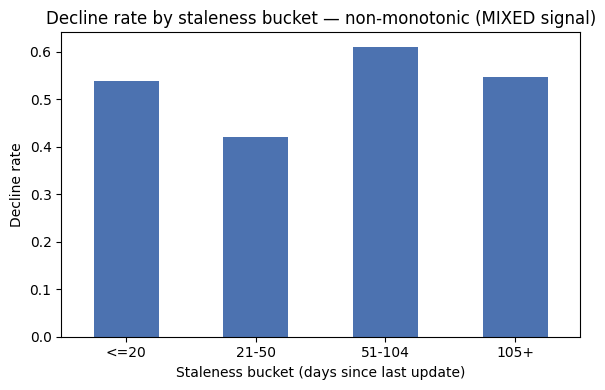

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
decay_table['mean'].plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_ylabel("Decline rate")
ax.set_xlabel("Staleness bucket (days since last update)")
ax.set_title("Decline rate by staleness bucket — non-monotonic (MIXED signal)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("work/figures/decline_rate_by_staleness_bucket.png", dpi=150)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.